<a href="https://colab.research.google.com/github/yneeraj18/MLA---0204-ML/blob/main/problem%203.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import numpy as np
import math

# Define a class for the decision tree node
class DecisionTreeNode:
    def __init__(self, attribute=None, label=None, branches=None):
        self.attribute = attribute  # the attribute used to split the data
        self.label = label  # the label assigned to this node
        self.branches = branches if branches is not None else {}  # the branches of the decision tree

# Define a function to calculate the entropy of a dataset
def entropy(data):
    target = data['Target']
    n = len(target)
    unique, counts = np.unique(target, return_counts=True)
    entropy = 0
    for i in range(len(unique)):
        p = counts[i] / n
        entropy -= p * math.log2(p)
    return entropy

# Define a function to calculate the information gain of an attribute
def information_gain(data, attribute):
    n = len(data)
    values = data[attribute].unique()
    entropy_s = entropy(data)
    entropy_attr = 0
    for value in values:
        subset = data[data[attribute] == value]
        subset_n = len(subset)
        subset_entropy = entropy(subset)
        entropy_attr += subset_n / n * subset_entropy
    return entropy_s - entropy_attr

# Define the ID3 algorithm
def id3(data, attributes):
    target = data['Target']
    # If all the examples have the same target value, return a leaf node with that value
    if len(target.unique()) == 1:
        return DecisionTreeNode(label=target.iloc[0])
    # If there are no attributes left to split on, return a leaf node with the most common target value
    if len(attributes) == 0:
        return DecisionTreeNode(label=target.value_counts().idxmax())
    # Otherwise, select the attribute with the highest information gain
    gains = {attr: information_gain(data, attr) for attr in attributes}
    best_attribute = max(gains, key=gains.get)
    # Create a new decision tree node with the selected attribute
    node = DecisionTreeNode(attribute=best_attribute)
    # Split the data based on the selected attribute and recursively build the tree
    for value in data[best_attribute].unique():
        subset = data[data[best_attribute] == value].drop(best_attribute, axis=1)
        if len(subset) == 0:
            node.branches[value] = DecisionTreeNode(label=target.value_counts().idxmax())
        else:
            new_attributes = attributes.copy()
            new_attributes.remove(best_attribute)
            node.branches[value] = id3(subset, new_attributes)
    return node

# Load the dataset
data = pd.read_csv('play_tennis.csv')
# Split the dataset into attributes and target variable
attributes = data.columns[:-1].tolist()
# Build the decision tree using ID3 algorithm
root = id3(data, attributes)

# Define a function to classify a new sample using the decision tree
def classify(sample, tree):
    if tree.label is not None:
        return tree.label
    attribute = tree.attribute
    value = sample[attribute]
    if value not in tree.branches:
        # Fallback to the branch with the most common label if the value is unseen
        return tree.branches[max(tree.branches.keys(), key=lambda k: len(str(k)))]
    subtree = tree.branches[value]
    return classify(sample, subtree)


In [3]:
# Define a new test sample (as a pandas Series)
new_sample = pd.Series({
    'Outlook': 'sunny',
    'Temperature': 'cool',
    'Humidity': 'normal',
    'Wind': 'strong'
})

# Classify the new sample using our constructed ID3 decision tree
prediction = classify(new_sample, root)

print("--- Test Sample ---")
print(new_sample.to_string())
print("-------------------")
print(f"Prediction (Play Tennis?): {prediction}")

--- Test Sample ---
Outlook         sunny
Temperature      cool
Humidity       normal
Wind           strong
-------------------
Prediction (Play Tennis?): yes


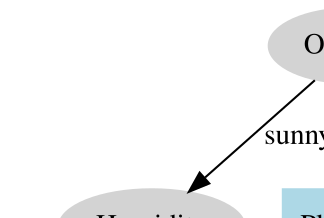

In [4]:
import graphviz

def export_tree_to_graphviz(tree, graph=None, parent_name=None, edge_label=None):
    if graph is None:
        graph = graphviz.Digraph(comment='ID3 Decision Tree', format='png')
        graph.attr(dpi='150')

    # Generate a unique identifier for the current node
    node_id = str(id(tree))

    if tree.label is not None:
        # Leaf Node
        graph.node(node_id, label=f"Play: {tree.label}", shape='box', style='filled', color='lightblue')
    else:
        # Decision Node
        graph.node(node_id, label=tree.attribute, shape='ellipse', style='filled', color='lightgrey')

    # If this is a child node, connect it to its parent
    if parent_name is not None:
        graph.edge(parent_name, node_id, label=edge_label)

    # Recursively add children
    if tree.branches:
        for value, child_node in tree.branches.items():
            export_tree_to_graphviz(child_node, graph, node_id, str(value))

    return graph

# Create the visualization and display it
tree_graph = export_tree_to_graphviz(root)
tree_graph